Random Seed: 999
Device: cuda:0
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Total images: 5600


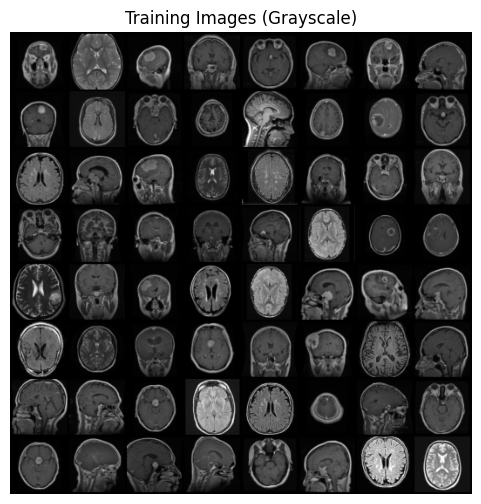

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


c:\Users\22958\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  [FID/KID] Real target: 512
  [FID/KID] Real progress: 512/512
  [FID/KID] Fake target: 512
  [FID/KID] Fake progress: 512/512 (batch 4/4)
[Eval][5/20] FID: 328.2913 | KID_mean: 0.408994 | KID_std: 0.006146

[6/20][0/43] Loss_D: 0.3307 Loss_G: 4.8543 D(x): 0.8755 D(G(z)): 0.0974/0.0145
[6/20][5/43] Loss_D: 0.4410 Loss_G: 8.4883 D(x): 0.9561 D(G(z)): 0.2943/0.0005
[6/20][10/43] Loss_D: 0.2038 Loss_G: 3.7834 D(x): 0.8992 D(G(z)): 0.0393/0.0401
[6/20][15/43] Loss_D: 0.2407 Loss_G: 4.7333 D(x): 0.8645 D(G(z)): 0.0483/0.0146
[6/20][20/43] Loss_D: 0.2971 Loss_G: 5.6415 D(x): 0.9103 D(G(z)): 0.1435/0.0072
[6/20][25/43] Loss_D: 0.3031 Loss_G: 4.2907 D(x): 0.8649 D(G(z)): 0.0625/0.0180
[6/20][30/43] Loss_D: 0.3696 Loss_G: 7.8268 D(x): 0.9509 D(G(z)): 0.2414/0.0010
[6/20][35/43] Loss_D: 0.4687 Loss_G: 2.3551 D(x): 0.7577 D(G(z)): 0.0396/0.1346
[6/20][40/43] Loss_D: 0.3211 Loss_G: 10.3577 D(x): 0.8237 D(G(z)): 0.0084/0.0008
[6/20][43/43] Loss_D: 0.3570 Loss_G: 6.1200 D(x): 0.9095 D(G(z)): 0.1360

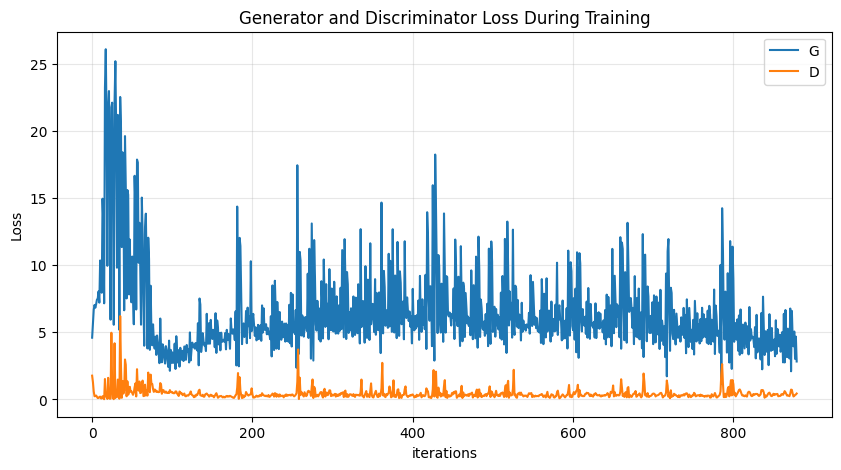

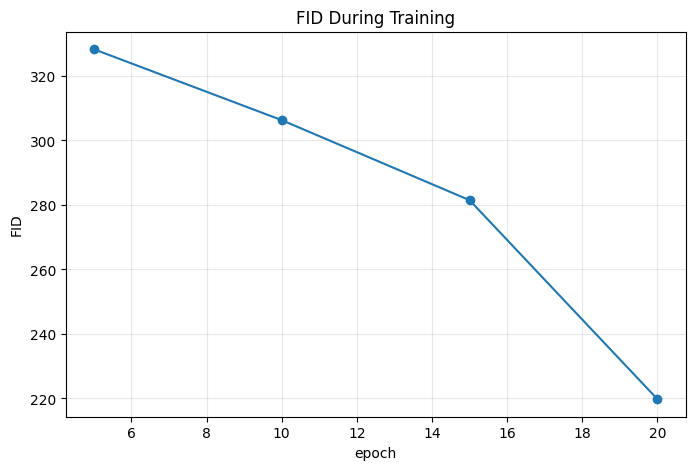

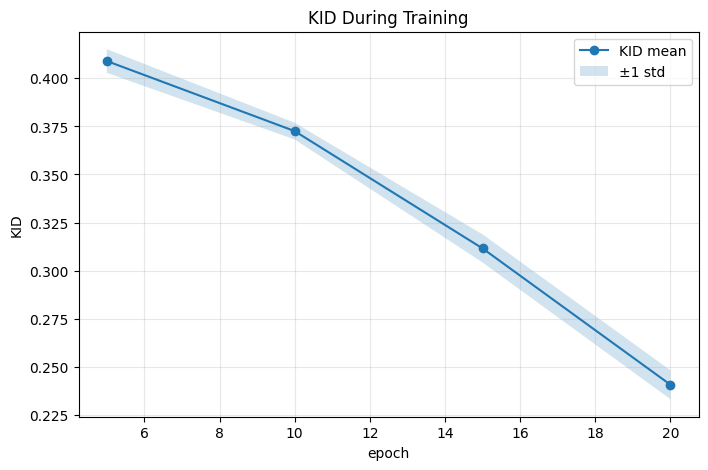

Done. Outputs saved to: ./dcgan_mri_outputs
Best FID: 219.7577 at epoch 20
KID at best-FID epoch: 0.240662 ± 0.007523
Best KID: 0.240662 ± 0.007523 at epoch 20
Saved summary to: ./dcgan_mri_outputs\best_metrics_summary.txt
Metrics CSV: ./dcgan_mri_outputs\metrics.csv


In [1]:
# =========================
# DCGAN for Grayscale MRI (ImageFolder)
# + FID / KID Evaluation
# + Better progress logs
# + Deterministic fix for CUDA FID/KID
# =========================

import os

# Must be set BEFORE importing torch
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import csv
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance


# -------------------------
# 0) Reproducibility
# -------------------------
manualSeed = 999
print("Random Seed:", manualSeed)
random.seed(manualSeed)
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(manualSeed)

# Keep deterministic for training, but we will temporarily disable it
# inside FID/KID evaluation to avoid CuBLAS deterministic errors.
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# -------------------------
# 1) Paths
# -------------------------
DATA_ROOT = r"C:\Users\22958\Desktop\毕业论文\archive\Training"
OUT_DIR = r"./dcgan_mri_outputs"
os.makedirs(OUT_DIR, exist_ok=True)


# -------------------------
# 2) Hyperparameters
# -------------------------
workers = 0
batch_size = 128
image_size = 64
nc = 1
nz = 100
ngf = 64
ndf = 64
num_epochs = 20
lr = 0.0002
beta1 = 0.5
ngpu = 1

# Logging / evaluation settings
print_every = 5          # print every 5 batches during training
eval_every = 5           # evaluate FID/KID every 5 epochs
num_eval_fake = 512      # reduce for speed; can increase later
kid_subsets = 10
kid_subset_size_cap = 100

device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print("Device:", device)


# -------------------------
# 3) Dataset & DataLoader
# -------------------------
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),   # [-1, 1]
])

dataset = dset.ImageFolder(root=DATA_ROOT, transform=transform)
print("Classes:", dataset.classes)
print("Total images:", len(dataset))

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=workers,
    pin_memory=(device.type == "cuda"),
)

eval_dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=workers,
    pin_memory=(device.type == "cuda"),
)


# -------------------------
# 4) Visualize a batch
# -------------------------
real_batch = next(iter(dataloader))
plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Training Images (Grayscale)")
grid = vutils.make_grid(real_batch[0][:64], padding=2, normalize=True)
plt.imshow(grid[0], cmap="gray")
plt.show()


# -------------------------
# 5) Weight init
# -------------------------
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)


# -------------------------
# 6) Models (DCGAN)
# -------------------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # input Z: (nz) x 1 x 1
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            # (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            # (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            # (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()   # output in [-1, 1]
        )

    def forward(self, x):
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # input: (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)


netG = Generator().to(device)
netD = Discriminator().to(device)
netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)


# -------------------------
# 7) Loss & Optimizers
# -------------------------
criterion = nn.BCELoss()

fixed_noise = torch.randn(64, nz, 1, 1, device=device)

real_label = 1.0
fake_label = 0.0

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))


# -------------------------
# 8) Helpers for FID / KID
# -------------------------
def to_metric_input(x):
    """
    Convert images from [-1, 1] grayscale to [0, 1] 3-channel RGB
    for Inception-based FID/KID.
    """
    x = ((x + 1.0) / 2.0).clamp(0, 1)   # [-1,1] -> [0,1]
    if x.size(1) == 1:
        x = x.repeat(1, 3, 1, 1)        # 1-channel -> 3-channel
    return x


@torch.no_grad()
def evaluate_fid_kid(netG, eval_dataloader, device, nz, batch_size, total_fake_count):
    """
    Compute FID and KID.
    Temporarily disable deterministic algorithms to avoid CuBLAS runtime error.
    """
    was_training = netG.training
    netG.eval()

    det_enabled = torch.are_deterministic_algorithms_enabled()
    if det_enabled:
        torch.use_deterministic_algorithms(False)

    try:
        fid = FrechetInceptionDistance(
            feature=2048,
            normalize=True
        ).to(device)
        fid.set_dtype(torch.float64)

        kid_subset_size = max(
            2,
            min(kid_subset_size_cap, len(dataset), total_fake_count)
        )

        kid = KernelInceptionDistance(
            feature=2048,
            subsets=kid_subsets,
            subset_size=kid_subset_size,
            normalize=True
        ).to(device)

        # ----- real images -----
        real_seen = 0
        real_target = total_fake_count

        print(f"  [FID/KID] Real target: {real_target}")
        for batch_idx, (real_imgs, _) in enumerate(eval_dataloader):
            real_imgs = real_imgs.to(device, non_blocking=True)
            real_imgs = to_metric_input(real_imgs)

            # only keep up to real_target
            if real_seen + real_imgs.size(0) > real_target:
                real_imgs = real_imgs[: real_target - real_seen]

            fid.update(real_imgs, real=True)
            kid.update(real_imgs, real=True)

            real_seen += real_imgs.size(0)

            if (batch_idx + 1) % 5 == 0 or real_seen >= real_target:
                print(f"  [FID/KID] Real progress: {real_seen}/{real_target}")

            if real_seen >= real_target:
                break

        # ----- fake images -----
        fake_generated = 0
        fake_batches = math.ceil(total_fake_count / batch_size)
        print(f"  [FID/KID] Fake target: {total_fake_count}")

        batch_counter = 0
        while fake_generated < total_fake_count:
            cur_bs = min(batch_size, total_fake_count - fake_generated)
            noise = torch.randn(cur_bs, nz, 1, 1, device=device)
            fake_imgs = netG(noise)
            fake_imgs = to_metric_input(fake_imgs)

            fid.update(fake_imgs, real=False)
            kid.update(fake_imgs, real=False)

            fake_generated += cur_bs
            batch_counter += 1

            if batch_counter % 5 == 0 or fake_generated >= total_fake_count:
                print(f"  [FID/KID] Fake progress: {fake_generated}/{total_fake_count} "
                      f"(batch {batch_counter}/{fake_batches})")

        fid_value = fid.compute().item()
        kid_mean, kid_std = kid.compute()
        kid_mean = kid_mean.item()
        kid_std = kid_std.item()

    finally:
        if det_enabled:
            torch.use_deterministic_algorithms(True)
        if was_training:
            netG.train()

    return fid_value, kid_mean, kid_std


# -------------------------
# 9) Training Loop
# -------------------------
G_losses = []
D_losses = []
FID_scores = []
KID_means = []
KID_stds = []
eval_epochs = []

iters = 0

metrics_csv = os.path.join(OUT_DIR, "metrics.csv")
with open(metrics_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "FID", "KID_mean", "KID_std", "G_loss_last", "D_loss_last"])

print("Starting Training Loop...")
for epoch in range(num_epochs):
    for i, (imgs, _) in enumerate(dataloader):
        # ---------------------
        # (1) Update D
        # ---------------------
        netD.zero_grad()
        real_cpu = imgs.to(device, non_blocking=True)
        b_size = real_cpu.size(0)

        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        # ---------------------
        # (2) Update G
        # ---------------------
        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Print more frequently
        if (i % print_every == 0) or (i == len(dataloader) - 1):
            print(f"[{epoch+1}/{num_epochs}][{i}/{len(dataloader)-1}] "
                  f"Loss_D: {errD.item():.4f} "
                  f"Loss_G: {errG.item():.4f} "
                  f"D(x): {D_x:.4f} "
                  f"D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}")

        # Save samples
        if (iters % 500 == 0) or ((epoch == num_epochs - 1) and (i == len(dataloader) - 1)):
            with torch.no_grad():
                fake_fixed = netG(fixed_noise).detach().cpu()
            sample_path = os.path.join(OUT_DIR, f"fake_epoch{epoch+1}_iter{iters}.png")
            vutils.save_image(fake_fixed, sample_path, normalize=True, nrow=8)
            print("Saved:", sample_path)

        iters += 1

    # Save checkpoints every epoch
    torch.save(netG.state_dict(), os.path.join(OUT_DIR, f"netG_epoch{epoch+1}.pth"))
    torch.save(netD.state_dict(), os.path.join(OUT_DIR, f"netD_epoch{epoch+1}.pth"))
    print(f"Epoch {epoch+1} finished. Checkpoints saved.")

    # Evaluate FID / KID every eval_every epochs
    if (epoch + 1) % eval_every == 0:
        print(f"\nEvaluating FID/KID at epoch {epoch+1} ...")
        fid_value, kid_mean, kid_std = evaluate_fid_kid(
            netG=netG,
            eval_dataloader=eval_dataloader,
            device=device,
            nz=nz,
            batch_size=batch_size,
            total_fake_count=num_eval_fake
        )

        FID_scores.append(fid_value)
        KID_means.append(kid_mean)
        KID_stds.append(kid_std)
        eval_epochs.append(epoch + 1)

        print(f"[Eval][{epoch+1}/{num_epochs}] "
              f"FID: {fid_value:.4f} | "
              f"KID_mean: {kid_mean:.6f} | "
              f"KID_std: {kid_std:.6f}\n")

        with open(metrics_csv, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch + 1,
                fid_value,
                kid_mean,
                kid_std,
                G_losses[-1] if len(G_losses) > 0 else None,
                D_losses[-1] if len(D_losses) > 0 else None
            ])


# -------------------------
# 10) Plot loss curves
# -------------------------
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUT_DIR, "loss_curve.png"), bbox_inches="tight")
plt.show()


# -------------------------
# 11) Plot FID / KID curves
# -------------------------
if len(FID_scores) > 0:
    plt.figure(figsize=(8, 5))
    plt.title("FID During Training")
    plt.plot(eval_epochs, FID_scores, marker="o")
    plt.xlabel("epoch")
    plt.ylabel("FID")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(OUT_DIR, "fid_curve.png"), bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.title("KID During Training")
    plt.plot(eval_epochs, KID_means, marker="o", label="KID mean")
    lower = np.array(KID_means) - np.array(KID_stds)
    upper = np.array(KID_means) + np.array(KID_stds)
    plt.fill_between(eval_epochs, lower, upper, alpha=0.2, label="±1 std")
    plt.xlabel("epoch")
    plt.ylabel("KID")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(OUT_DIR, "kid_curve.png"), bbox_inches="tight")
    plt.show()


# -------------------------
# 12) Final summary
# -------------------------
summary_txt = os.path.join(OUT_DIR, "best_metrics_summary.txt")

print("Done. Outputs saved to:", OUT_DIR)

with open(summary_txt, "w", encoding="utf-8") as f:
    f.write(f"Outputs saved to: {OUT_DIR}\n")

    if len(FID_scores) > 0:
        best_fid_idx = int(np.nanargmin(FID_scores))
        best_fid = FID_scores[best_fid_idx]
        best_epoch = eval_epochs[best_fid_idx]

        print(f"Best FID: {best_fid:.4f} at epoch {best_epoch}")
        f.write(f"Best FID: {best_fid:.4f} at epoch {best_epoch}\n")

        if best_fid_idx < len(KID_means):
            print(f"KID at best-FID epoch: {KID_means[best_fid_idx]:.6f} ± {KID_stds[best_fid_idx]:.6f}")
            f.write(f"KID at best-FID epoch: {KID_means[best_fid_idx]:.6f} ± {KID_stds[best_fid_idx]:.6f}\n")

    if len(KID_means) > 0:
        best_kid_idx = int(np.nanargmin(KID_means))
        best_kid_epoch = eval_epochs[best_kid_idx]

        print(f"Best KID: {KID_means[best_kid_idx]:.6f} ± {KID_stds[best_kid_idx]:.6f} at epoch {best_kid_epoch}")
        f.write(f"Best KID: {KID_means[best_kid_idx]:.6f} ± {KID_stds[best_kid_idx]:.6f} at epoch {best_kid_epoch}\n")

print("Saved summary to:", summary_txt)
print("Metrics CSV:", metrics_csv)

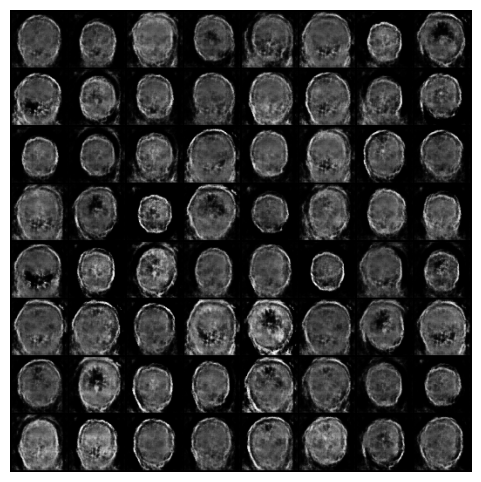

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(r"./dcgan_mri_outputs/fake_epoch20_iter879.png")
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()
